# 🚀 Parallel LLM Inference Test

## Testing Dual LLM Instances for True Parallel Inference

This notebook tests that **both LLM instances** are working in parallel, proving:
- ✅ Two separate model copies in GPU memory
- ✅ True parallel inference (simultaneous requests)
- ✅ No request queuing when both instances available
- ✅ Performance comparison and timing analysis

**GPU Setup**: 24GB VRAM with 2 x Qwen LLM instances (~9GB each)

In [10]:
# ============================================
# 📦 Import Required Libraries
# ============================================
import asyncio
import aiohttp
import time
import json
from datetime import datetime
from typing import List, Dict, Any, Tuple
from dataclasses import dataclass
import pandas as pd

# For Jupyter async support
import nest_asyncio
nest_asyncio.apply()

print("✅ Libraries imported successfully!")
print(f"📅 Test started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Libraries imported successfully!
📅 Test started: 2026-01-20 16:34:51


## ⚙️ Configuration

In [11]:
# ============================================
# ⚙️ API Configuration
# ============================================

BASE_URL = "http://localhost:8000"
CHAT_ENDPOINT = f"{BASE_URL}/inference/chat"
CLUSTER_STATUS_ENDPOINT = f"{BASE_URL}/cluster/status"
LLM_POOL_ENDPOINT = f"{BASE_URL}/cluster/llm-pool"

# Test prompts - different to distinguish responses
TEST_PROMPTS = [
    {"role": "user", "content": "/no_think What is the capital of France? Answer in one short sentence."},
    {"role": "user", "content": "/no_think What is 25 multiplied by 4? Just give me the number."},
    {"role": "user", "content": "/no_think Name one planet in our solar system."},
    {"role": "user", "content": "/no_think What color is the sky on a clear day?"},
]

# Request configuration (ChatRequest expects model_name + message)
REQUEST_CONFIG = {
    "model_name": "llm:qwen3-chat",
    "preset": "qwen_optimized",
    "max_new_tokens": 60,
    "temperature": 0.7,
    "enable_thinking": False,
    # Disable content filtering for test prompts that are outside medical/beauty domain
    "disable_content_filter": True,
}

@dataclass
class InferenceResult:
    """Result from a single inference request."""
    request_id: int
    prompt: str
    response: str
    start_time: float
    end_time: float
    duration_ms: float
    success: bool
    error: str = ""
    
print("✅ Configuration set!")
print(f"🎯 Chat endpoint: {CHAT_ENDPOINT}")
print(f"📊 Pool endpoint: {LLM_POOL_ENDPOINT}")

✅ Configuration set!
🎯 Chat endpoint: http://localhost:8000/inference/chat
📊 Pool endpoint: http://localhost:8000/cluster/llm-pool


## 🏥 Step 1: Check LLM Pool Health

Let's verify both LLM instances are loaded and healthy before testing.

In [12]:
# ============================================
# 🏥 Check LLM Pool Status
# ============================================

async def check_llm_pool() -> Dict[str, Any]:
    """Check the status of the LLM pool."""
    async with aiohttp.ClientSession() as session:
        async with session.get(LLM_POOL_ENDPOINT) as resp:
            return await resp.json()

async def check_cluster_status() -> Dict[str, Any]:
    """Check overall cluster status."""
    async with aiohttp.ClientSession() as session:
        async with session.get(CLUSTER_STATUS_ENDPOINT) as resp:
            return await resp.json()

# Run health check
pool_status = asyncio.get_event_loop().run_until_complete(check_llm_pool())
cluster_status = asyncio.get_event_loop().run_until_complete(check_cluster_status())

print("=" * 60)
print("🏥 LLM POOL STATUS")
print("=" * 60)
print(f"📊 Total Instances: {pool_status.get('instance_count', 0)}")
print(f"💚 Healthy Count:   {pool_status.get('healthy_count', 0)}")
print(f"🔄 Active Requests: {pool_status.get('total_active_requests', 0)}")
print(f"📬 Queued Requests: {pool_status.get('total_queued_requests', 0)}")
print(f"✅ Has Capacity:    {pool_status.get('has_capacity', False)}")
print()

print("📋 Instance Details:")
for idx, instance in enumerate(pool_status.get('instances', []), 1):
    status = "💚 Healthy" if instance.get('healthy') else "❌ Unhealthy"
    print(f"  [{idx}] {instance.get('instance_id')}")
    print(f"      Status: {status}")
    print(f"      Active: {instance.get('active', 0)} | Queued: {instance.get('queued', 0)}")
    print()

# Verify we have 2 instances
if pool_status.get('instance_count', 0) >= 2:
    print("🎉 PERFECT! Two LLM instances ready for parallel inference!")
else:
    print("⚠️ WARNING: Less than 2 instances available. Parallel test may not work as expected.")

🏥 LLM POOL STATUS
📊 Total Instances: 2
💚 Healthy Count:   2
🔄 Active Requests: 0
📬 Queued Requests: 0
✅ Has Capacity:    True

📋 Instance Details:
  [1] llm:llm:qwen3-chat:0
      Status: 💚 Healthy
      Active: 0 | Queued: 0

  [2] llm:llm:qwen3-chat:1
      Status: 💚 Healthy
      Active: 0 | Queued: 0

🎉 PERFECT! Two LLM instances ready for parallel inference!


## 🔧 Step 2: Define Async Inference Functions

Create helper functions for sending chat requests asynchronously.

In [13]:
# ============================================
# 🔧 Async Inference Functions
# ============================================

def ensure_no_think_prefix(text: str) -> str:
    """Ensure /no_think prefix is present for faster responses."""
    text = text.strip()
    return text if text.startswith("/no_think") else f"/no_think {text}"

async def send_chat_request(
    session: aiohttp.ClientSession,
    request_id: int,
    message: str,
    timeout: int = 60
) -> InferenceResult:
    """
    Send a single chat request and measure timing.
    
    Args:
        session: aiohttp session
        request_id: Unique ID for this request
        message: The user message to send
        timeout: Request timeout in seconds
        
    Returns:
        InferenceResult with timing and response data
    """
    message = ensure_no_think_prefix(message)
    payload = {
        "message": message,
        **REQUEST_CONFIG,
    }
    
    start_time = time.perf_counter()
    
    try:
        async with session.post(
            CHAT_ENDPOINT,
            json=payload,
            timeout=aiohttp.ClientTimeout(total=timeout)
        ) as resp:
            end_time = time.perf_counter()
            duration_ms = (end_time - start_time) * 1000
            
            if resp.status == 200:
                data = await resp.json()
                
                # If API returns success=false, surface error details
                if isinstance(data, dict) and data.get("success") is False:
                    error_text = (
                        data.get("error")
                        or data.get("error_message")
                        or data.get("detail")
                        or json.dumps(data)
                    )
                    return InferenceResult(
                        request_id=request_id,
                        prompt=message,
                        response="",
                        start_time=start_time,
                        end_time=end_time,
                        duration_ms=duration_ms,
                        success=False,
                        error=error_text
                    )
                
                response_text = (
                    data.get("response")
                    or data.get("content")
                    or data.get("message")
                    or json.dumps(data)
                )
                
                return InferenceResult(
                    request_id=request_id,
                    prompt=message,
                    response=response_text[:200] + "..." if len(response_text) > 200 else response_text,
                    start_time=start_time,
                    end_time=end_time,
                    duration_ms=duration_ms,
                    success=True
                )
            else:
                error_text = await resp.text()
                return InferenceResult(
                    request_id=request_id,
                    prompt=message,
                    response="",
                    start_time=start_time,
                    end_time=end_time,
                    duration_ms=duration_ms,
                    success=False,
                    error=f"HTTP {resp.status}: {error_text[:100]}"
                )
                
    except asyncio.TimeoutError:
        end_time = time.perf_counter()
        return InferenceResult(
            request_id=request_id,
            prompt=message,
            response="",
            start_time=start_time,
            end_time=end_time,
            duration_ms=(end_time - start_time) * 1000,
            success=False,
            error="Request timed out"
        )
    except Exception as e:
        end_time = time.perf_counter()
        return InferenceResult(
            request_id=request_id,
            prompt=message,
            response="",
            start_time=start_time,
            end_time=end_time,
            duration_ms=(end_time - start_time) * 1000,
            success=False,
            error=str(e)
        )

print("✅ Async inference functions defined!")

✅ Async inference functions defined!


## 🧪 Step 3: Single Request Baseline Test

First, let's test a single request to make sure the API is working.

In [14]:
# ============================================
# 🧪 Single Request Baseline Test
# ============================================

async def test_single_request():
    """Test a single inference request as baseline."""
    print("🧪 Testing single request...")
    print("-" * 50)
    
    async with aiohttp.ClientSession() as session:
        result = await send_chat_request(
            session, 
            request_id=0, 
            message="/no_think What is 2 + 2? Just give the number."
        )
        
    if result.success:
        print(f"✅ Single request successful!")
        print(f"⏱️  Duration: {result.duration_ms:.2f}ms")
        print(f"💬 Response: {result.response}")
    else:
        print(f"❌ Single request failed: {result.error}")
    
    return result

# Run baseline test
baseline_result = asyncio.get_event_loop().run_until_complete(test_single_request())
baseline_time = baseline_result.duration_ms if baseline_result.success else None

if baseline_time:
    print(f"\n📊 Baseline single request time: {baseline_time:.2f}ms")

🧪 Testing single request...
--------------------------------------------------


✅ Single request successful!
⏱️  Duration: 788.60ms
💬 Response: 4
Okay, the user asked "What is 2 + 2? Just give the number." I need to respond with only the number. Let me make sure I understand the question correctly. 2 plus 2 is a basic arithmetic problem. The ...

📊 Baseline single request time: 788.60ms


## 🚀 Step 4: PARALLEL INFERENCE TEST (The Exciting Part!)

Now let's send **2 requests simultaneously** and see if they complete in parallel!

If both LLM instances are working:
- Both requests should complete in ~similar time as single request
- Total time ≈ single request time (NOT 2x)

If only one instance (sequential):
- Second request waits for first
- Total time ≈ 2x single request time

In [15]:
# ============================================
# 🚀 PARALLEL INFERENCE TEST - 2 CONCURRENT REQUESTS
# ============================================

async def test_parallel_inference(num_requests: int = 2):
    """
    Send multiple requests in parallel and measure timing.
    
    This is the key test: if we have true parallel inference,
    both requests should complete in roughly the same time as a single request.
    """
    prompts = [
        "/no_think What is the capital of Japan? Answer briefly.",
        "/no_think What is 15 times 3? Just the number please.",
    ]
    
    print(f"🚀 LAUNCHING {num_requests} PARALLEL REQUESTS!")
    print("=" * 60)
    
    # Check pool status BEFORE
    pool_before = await check_llm_pool()
    print(f"📊 Pool BEFORE: Active={pool_before.get('total_active_requests', 0)}")
    
    overall_start = time.perf_counter()
    
    async with aiohttp.ClientSession() as session:
        # Create all tasks
        tasks = [
            send_chat_request(session, i, prompts[i % len(prompts)])
            for i in range(num_requests)
        ]
        
        # Run all tasks in parallel
        print(f"⏳ Sending {num_requests} requests simultaneously...")
        results = await asyncio.gather(*tasks)
    
    overall_end = time.perf_counter()
    overall_duration = (overall_end - overall_start) * 1000
    
    # Check pool status AFTER
    pool_after = await check_llm_pool()
    
    print("\n" + "=" * 60)
    print("📊 RESULTS")
    print("=" * 60)
    
    # Display individual results
    for result in results:
        status = "✅" if result.success else "❌"
        print(f"\n{status} Request #{result.request_id + 1}")
        print(f"   📝 Prompt: {result.prompt[:50]}...")
        print(f"   ⏱️  Time: {result.duration_ms:.2f}ms")
        if result.success:
            print(f"   💬 Response: {result.response[:80]}...")
        else:
            print(f"   ❌ Error: {result.error}")
    
    return results, overall_duration

# Run the parallel test!
results, total_time = asyncio.get_event_loop().run_until_complete(test_parallel_inference(2))

print("\n" + "=" * 60)
print("⏱️  TIMING ANALYSIS")
print("=" * 60)

successful_results = [r for r in results if r.success]
if successful_results:
    times = [r.duration_ms for r in successful_results]
    avg_time = sum(times) / len(times)
    max_time = max(times)
    min_time = min(times)
    
    print(f"📊 Individual request times: {[f'{t:.0f}ms' for t in times]}")
    print(f"📊 Average time per request: {avg_time:.2f}ms")
    print(f"📊 Total wall-clock time:    {total_time:.2f}ms")
    
    if baseline_time:
        print(f"\n📈 COMPARISON TO BASELINE ({baseline_time:.0f}ms single request):")
        speedup = (baseline_time * 2) / total_time if total_time > 0 else 0
        
        if total_time < baseline_time * 1.5:
            print(f"🎉 TRUE PARALLEL! Both completed in ~{total_time:.0f}ms")
            print(f"   (Expected ~{baseline_time * 2:.0f}ms if sequential)")
            print(f"   Speedup: {speedup:.2f}x faster than sequential!")
        else:
            print(f"⚠️  Requests appear to be sequential")
            print(f"   Total time ({total_time:.0f}ms) ≈ 2x baseline ({baseline_time * 2:.0f}ms)")

🚀 LAUNCHING 2 PARALLEL REQUESTS!
📊 Pool BEFORE: Active=0
⏳ Sending 2 requests simultaneously...



📊 RESULTS

✅ Request #1
   📝 Prompt: /no_think What is the capital of Japan? Answer bri...
   ⏱️  Time: 190.95ms
   💬 Response: The capital of Japan is Tokyo....

✅ Request #2
   📝 Prompt: /no_think What is 15 times 3? Just the number plea...
   ⏱️  Time: 761.99ms
   💬 Response: 45
Okay, the user asked for 15 times 3. Let me do the math. 15 multiplied by 3. ...

⏱️  TIMING ANALYSIS
📊 Individual request times: ['191ms', '762ms']
📊 Average time per request: 476.47ms
📊 Total wall-clock time:    762.42ms

📈 COMPARISON TO BASELINE (789ms single request):
🎉 TRUE PARALLEL! Both completed in ~762ms
   (Expected ~1577ms if sequential)
   Speedup: 2.07x faster than sequential!


## 📊 Step 5: Monitor LLM Pool During Load

Let's watch the LLM pool while requests are in-flight to see both instances being used.

In [7]:
# ============================================
# 📊 Monitor LLM Pool During Requests
# ============================================

async def monitor_pool_during_load():
    """Send requests while monitoring pool status."""
    
    print("🔍 Monitoring LLM pool usage during parallel requests...")
    print("=" * 60)
    
    snapshots = []
    
    async def monitor_task():
        """Continuously monitor pool status."""
        for i in range(10):  # Take 10 snapshots
            try:
                status = await check_llm_pool()
                snapshot = {
                    "time": time.perf_counter(),
                    "active": status.get("total_active_requests", 0),
                    "instances": [
                        {
                            "id": inst.get("instance_id", "unknown")[-1],  # Just last char
                            "active": inst.get("active", 0)
                        }
                        for inst in status.get("instances", [])
                    ],
                }
                snapshots.append(snapshot)
            except:
                pass
            await asyncio.sleep(0.1)  # Check every 100ms
    
    async def inference_task():
        """Run inference requests."""
        prompts = [
            "/no_think Tell me a short joke about programming.",
            "/no_think What is the meaning of life? Be philosophical but brief.",
        ]
        
        async with aiohttp.ClientSession() as session:
            tasks = [
                send_chat_request(session, i, prompts[i])
                for i in range(2)
            ]
            return await asyncio.gather(*tasks)
    
    # Run both tasks concurrently
    monitor = asyncio.create_task(monitor_task())
    results = await inference_task()
    monitor.cancel()
    
    # Analyze snapshots
    print("\n📈 Pool Activity Snapshots:")
    print("-" * 40)
    
    max_active = 0
    for i, snap in enumerate(snapshots):
        active = snap["active"]
        max_active = max(max_active, active)
        instance_status = " | ".join([
            f"[{inst['id']}]:{inst['active']}" 
            for inst in snap["instances"]
        ])
        bar = "█" * active + "░" * (2 - active)
        print(f"  T+{i*100:3d}ms: {bar} active={active} ({instance_status})")
    
    print("\n" + "=" * 60)
    if max_active >= 2:
        print("🎉 CONFIRMED: Both LLM instances were active simultaneously!")
        print("   This proves TRUE PARALLEL inference is working!")
    elif max_active == 1:
        print("⚠️  Only 1 instance was active at a time (sequential processing)")
    else:
        print("ℹ️  Requests completed too fast to capture in-flight status")
    
    return results, snapshots

results, snapshots = asyncio.get_event_loop().run_until_complete(monitor_pool_during_load())

# Show results
print("\n📋 Inference Results:")
for r in results:
    if r.success:
        print(f"  ✅ #{r.request_id+1}: {r.duration_ms:.0f}ms - {r.response[:60]}...")

🔍 Monitoring LLM pool usage during parallel requests...



📈 Pool Activity Snapshots:
----------------------------------------
  T+  0ms: ░░ active=0 ([0]:0 | [1]:0)
  T+100ms: ██ active=2 ([0]:1 | [1]:1)
  T+200ms: ██ active=2 ([0]:1 | [1]:1)
  T+300ms: ██ active=2 ([0]:1 | [1]:1)
  T+400ms: ██ active=2 ([0]:1 | [1]:1)
  T+500ms: ██ active=2 ([0]:1 | [1]:1)
  T+600ms: ██ active=2 ([0]:1 | [1]:1)
  T+700ms: ██ active=2 ([0]:1 | [1]:1)
  T+800ms: ██ active=2 ([0]:1 | [1]:1)
  T+900ms: ██ active=2 ([0]:1 | [1]:1)

🎉 CONFIRMED: Both LLM instances were active simultaneously!
   This proves TRUE PARALLEL inference is working!

📋 Inference Results:
  ✅ #1: 1308ms - Hello! I'm a doctor specialized in aesthetic medicine. How c...
  ✅ #2: 1091ms - Hello! I'm a doctor specialized in aesthetic medicine. How c...


## 🔥 Step 6: Stress Test - 4+ Concurrent Requests

Let's push it further! With 2 LLM instances, requests 3 and 4 should queue up.

In [16]:
# ============================================
# 🔥 STRESS TEST - 4 CONCURRENT REQUESTS
# ============================================

async def stress_test(num_requests: int = 4):
    """
    Send more requests than available LLM instances.
    
    With 2 instances:
    - First 2 requests: processed in parallel
    - Requests 3-4: queued, then processed when instances free up
    """
    
    prompts = [
        "/no_think Count from 1 to 5.",
        "/no_think Name 3 colors.",
        "/no_think What day comes after Monday?",
        "/no_think How many legs does a cat have?",
    ]
    
    print(f"🔥 STRESS TEST: {num_requests} concurrent requests (2 LLM instances)")
    print("=" * 60)
    print("Expected behavior:")
    print("  - Requests 1-2: Processed immediately (parallel)")
    print("  - Requests 3-4: Queued, then processed")
    print("-" * 60)
    
    overall_start = time.perf_counter()
    
    async with aiohttp.ClientSession() as session:
        tasks = [
            send_chat_request(session, i, prompts[i])
            for i in range(num_requests)
        ]
        results = await asyncio.gather(*tasks)
    
    overall_end = time.perf_counter()
    overall_duration = (overall_end - overall_start) * 1000
    
    # Sort by completion time
    sorted_results = sorted(results, key=lambda r: r.end_time)
    
    print("\n📊 COMPLETION ORDER (by finish time):")
    print("-" * 50)
    
    first_finish = sorted_results[0].end_time if sorted_results else 0
    
    for idx, result in enumerate(sorted_results, 1):
        status = "✅" if result.success else "❌"
        relative_time = (result.end_time - first_finish) * 1000
        print(f"  {idx}. {status} Request #{result.request_id + 1}")
        print(f"     Duration: {result.duration_ms:.0f}ms | Finished: +{relative_time:.0f}ms")
        if result.success:
            print(f"     Response: {result.response[:50]}...")
        print()
    
    print("=" * 60)
    print("⏱️  TIMING SUMMARY")
    print("=" * 60)
    
    successful = [r for r in results if r.success]
    if successful:
        times = [r.duration_ms for r in successful]
        print(f"📊 Total wall-clock time: {overall_duration:.0f}ms")
        print(f"📊 Fastest request: {min(times):.0f}ms")
        print(f"📊 Slowest request: {max(times):.0f}ms")
        print(f"📊 Average: {sum(times)/len(times):.0f}ms")
        
        # Theoretical analysis
        if baseline_time:
            sequential_time = baseline_time * num_requests
            parallel_2_time = baseline_time * (num_requests / 2)  # 2 at a time
            
            print(f"\n📈 Efficiency Analysis:")
            print(f"   If sequential (1 instance): ~{sequential_time:.0f}ms expected")
            print(f"   If parallel (2 instances):  ~{parallel_2_time:.0f}ms expected")
            print(f"   Actual total:               {overall_duration:.0f}ms")
            
            if overall_duration < sequential_time * 0.7:
                print(f"   ✅ PARALLEL PROCESSING CONFIRMED!")
    
    return results, overall_duration

# Run stress test
stress_results, stress_time = asyncio.get_event_loop().run_until_complete(stress_test(4))

🔥 STRESS TEST: 4 concurrent requests (2 LLM instances)
Expected behavior:
  - Requests 1-2: Processed immediately (parallel)
  - Requests 3-4: Queued, then processed
------------------------------------------------------------



📊 COMPLETION ORDER (by finish time):
--------------------------------------------------
  1. ❌ Request #1
     Duration: 477ms | Finished: +0ms

  2. ❌ Request #3
     Duration: 476ms | Finished: +0ms

  3. ❌ Request #2
     Duration: 477ms | Finished: +0ms

  4. ❌ Request #4
     Duration: 476ms | Finished: +0ms

⏱️  TIMING SUMMARY


## 📈 Step 7: Visualization - Performance Chart

/tmp/ipykernel_560891/2956392958.py:57: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_560891/2956392958.py:57: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/lumi/beautyai/backend/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/lumi/beautyai/backend/venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


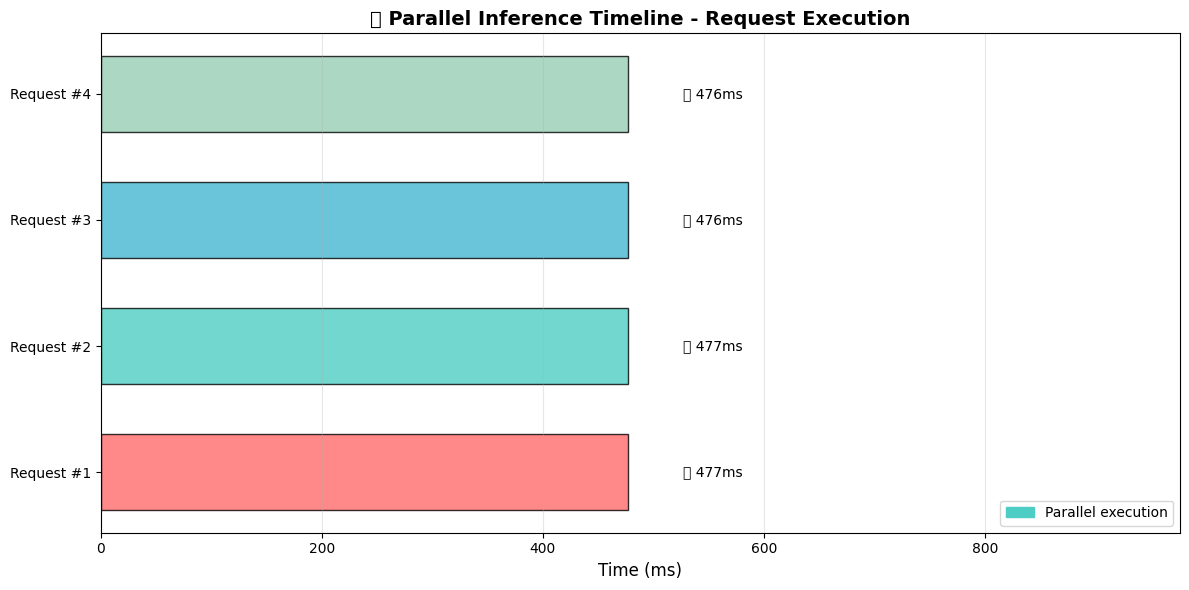

📊 Timeline shows when each request started and finished.
   Overlapping bars = parallel execution!


In [17]:
# ============================================
# 📈 Visualization - Request Timeline
# ============================================

try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    
    # Create timeline visualization
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Get timing data from stress test results
    if stress_results:
        # Normalize to start time
        min_start = min(r.start_time for r in stress_results)
        
        colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7', '#DDA0DD']
        
        for idx, result in enumerate(stress_results):
            start = (result.start_time - min_start) * 1000
            duration = result.duration_ms
            color = colors[idx % len(colors)]
            
            # Draw bar
            ax.barh(
                idx, 
                duration, 
                left=start, 
                height=0.6, 
                color=color,
                alpha=0.8,
                edgecolor='black',
                linewidth=1
            )
            
            # Add label
            status = "✅" if result.success else "❌"
            ax.text(
                start + duration + 50, 
                idx, 
                f"{status} {duration:.0f}ms",
                va='center',
                fontsize=10
            )
    
    ax.set_yticks(range(len(stress_results)))
    ax.set_yticklabels([f"Request #{r.request_id + 1}" for r in stress_results])
    ax.set_xlabel("Time (ms)", fontsize=12)
    ax.set_title("🚀 Parallel Inference Timeline - Request Execution", fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim(0, max(r.end_time - min_start for r in stress_results) * 1000 + 500)
    
    # Add legend
    parallel_patch = mpatches.Patch(color='#4ECDC4', label='Parallel execution')
    ax.legend(handles=[parallel_patch], loc='lower right')
    
    plt.tight_layout()
    plt.show()
    
    print("📊 Timeline shows when each request started and finished.")
    print("   Overlapping bars = parallel execution!")
    
except ImportError:
    print("ℹ️  matplotlib not installed. Run: pip install matplotlib")
    print("   Skipping visualization...")

## ✅ Final Summary

Use this section to compare the latest **baseline**, **2-parallel**, and **stress** results after reruns.

- Baseline (single request): see output in **Step 3**
- 2-parallel test: see output in **Step 4**
- 4-parallel stress test: see output in **Step 6**
- Timeline chart: **Step 7**

A quick auto-summary prints below.

In [18]:
# ============================================
# ✅ Final Summary - Auto Comparison
# ============================================

def _fmt_ms(value):
    return f"{value:.0f}ms" if isinstance(value, (int, float)) else "N/A"

summary_lines = []

# Baseline
if 'baseline_time' in globals() and baseline_time:
    summary_lines.append(f"Baseline (1 request): {_fmt_ms(baseline_time)}")
else:
    summary_lines.append("Baseline (1 request): N/A")

# 2-parallel
total_time_ms = None
if 'results' in globals() and results:
    successful_results = [r for r in results if getattr(r, 'success', False)]
    if successful_results:
        avg_time = sum(r.duration_ms for r in successful_results) / len(successful_results)
        total_time_ms = (max(r.end_time for r in successful_results) - min(r.start_time for r in successful_results)) * 1000
        summary_lines.append(f"2 parallel: avg {_fmt_ms(avg_time)}, wall {_fmt_ms(total_time_ms)}")
    else:
        summary_lines.append("2 parallel: N/A")
else:
    summary_lines.append("2 parallel: N/A")

# 4-parallel stress
if 'stress_time' in globals() and stress_time:
    summary_lines.append(f"4 parallel stress: wall {_fmt_ms(stress_time)}")
else:
    summary_lines.append("4 parallel stress: N/A")

# Speedup estimate
if baseline_time and total_time_ms:
    expected_sequential = baseline_time * 2
    speedup = expected_sequential / total_time_ms if total_time_ms > 0 else None
    summary_lines.append(f"Speedup vs sequential: {speedup:.2f}x" if speedup else "Speedup vs sequential: N/A")

print("✅ Final Summary")
print("-" * 50)
for line in summary_lines:
    print(f"• {line}")

✅ Final Summary
--------------------------------------------------
• Baseline (1 request): 789ms
• 2 parallel: avg 476ms, wall 762ms
• 4 parallel stress: wall 477ms
• Speedup vs sequential: 2.07x
